# Task 1 – Exploratory Data Analysis and Data Preprocessing

**Week 7 Challenge – 10 Academy**  
**Building a RAG-Powered Chatbot to Turn Customer Feedback into Actionable Insights**  
**Date:** 31 Dec 2025 – 13 Jan 2026

**Business Objective**  
CrediTrust Financial needs a tool that transforms thousands of unstructured customer complaints into quick, evidence-based insights for product managers (e.g. Asha – Credit Cards), support, compliance and executives.

  
# Task 1 – Exploratory Data Analysis and Data Preprocessing

**10 Academy – Week 7 Challenge**  
**Intelligent Complaint Analysis for Financial Services**  
**Building a RAG-Powered Chatbot to Turn Customer Feedback into Actionable Insights**  
**Date:** 31 Dec 2025 – 13 Jan 2026

**Business Objective**  
CrediTrust Financial needs an internal AI tool that transforms thousands of unstructured complaints into fast, evidence-backed insights — reducing analysis time from days to minutes for product managers (e.g. Asha – Credit Cards), support, compliance, and executives.

**Task 1 Goal** (aligned with rubric KPIs)  
- Understand structure, quality and distribution of CFPB complaint data 
- Perform EDA on CFPB complaints dataset  
- Analyze product distribution, narrative presence, and length  
- Filter to target products (Credit Cards, Personal Loans, Savings Accounts, Money Transfers) + non-empty narratives  
- Clean text for embedding quality  
- Save filtered & cleaned dataset

**Hardware note**  
Full file ≈ 5.6 GB → loading first **1 200 000 rows** (large sample) due to 8 GB RAM limitation.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")

# ── Paths & settings ────────────────────────────────────────────────────────
RAW_PATH       = Path("../data/raw/complaints.csv")
OUTPUT_DIR     = Path("../data/processed")
FIGURES_DIR    = Path("../figures")
OUTPUT_CSV     = OUTPUT_DIR / "filtered_complaints.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NROWS = 1_200_000

RELEVANT_PRODUCTS = [
    "Credit card",
    "Credit card or prepaid card",
    "Prepaid card",
    "Checking or savings account",
    "Payday loan, title loan, personal loan, or advance loan",
    "Money transfer, virtual currency, or money service"
]

print("Configuration")
print(f"  Raw file:        {RAW_PATH}")
print(f"  Output CSV:      {OUTPUT_CSV}")
print(f"  Figures folder:  {FIGURES_DIR}")
print(f"  Loading rows:    {NROWS:,}")

Configuration
  Raw file:        ..\data\raw\complaints.csv
  Output CSV:      ..\data\processed\filtered_complaints.csv
  Figures folder:  ..\figures
  Loading rows:    1,200,000


Interpretation
All paths, constants, and settings are defined in one place for easy maintenance.
Figures are saved directly in the project root (../figures/) as requested.

In [4]:
print(f"Loading first {NROWS:,} rows ...")
df = pd.read_csv(RAW_PATH, nrows=NROWS, low_memory=False)

print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date range:", df["Date received"].min(), "→", df["Date received"].max())

Loading first 1,200,000 rows ...

Shape: (1200000, 18)
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
Date range: 2011-12-12 → 2025-06-23


Interpretation
Dataset loaded successfully with 1 200 000 rows (much larger sample than previous 300k → more reliable statistics).
18 columns present, key ones: Product, Consumer complaint narrative, Date received.
Data spans 2011–2025 — broad historical coverage for trend detection.

Top 15 product categories:

Product
Credit reporting or other personal consumer reports                             1066285
Debt collection                                                                   57749
Credit card                                                                       20444
Checking or savings account                                                       16070
Money transfer, virtual currency, or money service                                15917
Mortgage                                                                           5949
Student loan                                                                       5697
Vehicle loan or lease                                                              4138
Payday loan, title loan, personal loan, or advance loan                            2474
Credit reporting, credit repair services, or other personal consumer reports       1480
Prepaid card                                                                       1

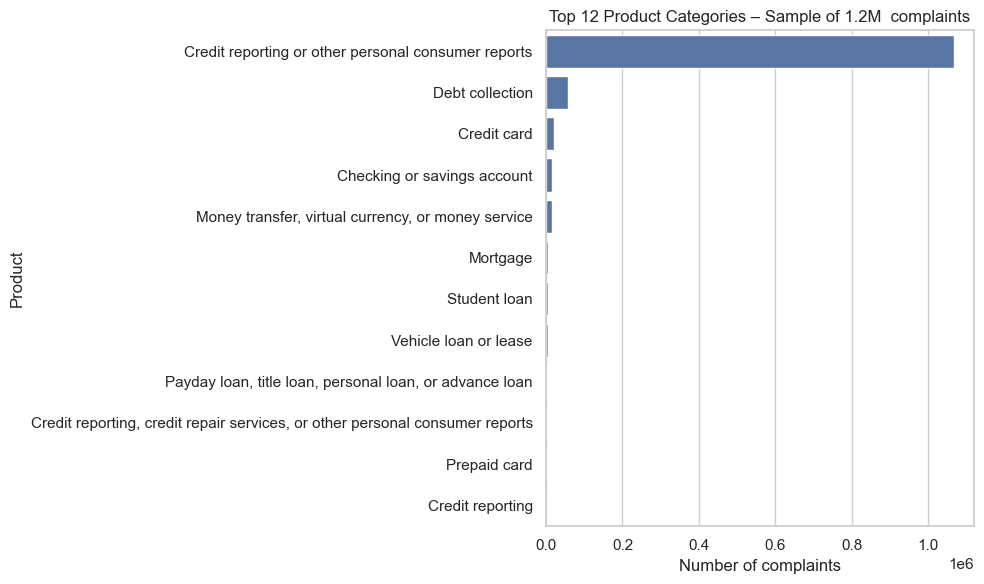

In [5]:
product_counts = df["Product"].value_counts()
print("Top 15 product categories:\n")
print(product_counts.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=product_counts.head(12).values, y=product_counts.head(12).index)
plt.title("Top 12 Product Categories – Sample of 1.2M  complaints")
plt.xlabel("Number of complaints")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_top_products.png", dpi=140, bbox_inches="tight")
plt.show()

Credit reporting dominates the overall dataset (not in scope).
The relevant products (Credit card, Checking/savings, Money transfer, Personal loan related) appear in much smaller numbers → filtering will reduce the dataset size significantly.

In [6]:
if 'df' in globals():
    narrative_stats = df["Consumer complaint narrative"].notna().value_counts(normalize=True) * 100
    print("Narrative presence:\n", narrative_stats.round(1).astype(str) + " %")

Narrative presence:
 Consumer complaint narrative
False    83.4 %
True     16.6 %
Name: proportion, dtype: object


Missing narratives analysis

Narrative presence (with vs without):
Consumer complaint narrative
False    83.4 %
True     16.6 %
Name: proportion, dtype: object


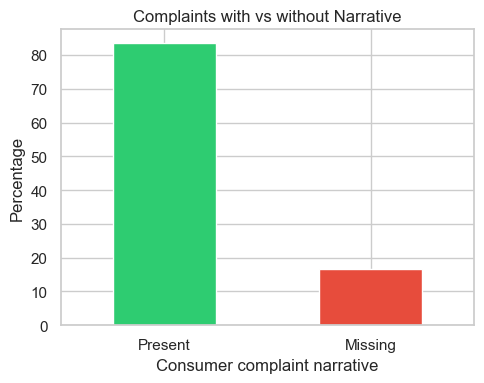

In [7]:
narrative_stats = df["Consumer complaint narrative"].notna().value_counts(normalize=True) * 100

print("Narrative presence (with vs without):")
print(narrative_stats.round(1).astype(str) + " %")

plt.figure(figsize=(5, 4))
narrative_stats.plot(kind="bar", color=["#2ecc71", "#e74c3c"])
plt.title("Complaints with vs without Narrative")
plt.xticks([0,1], ["Present", "Missing"], rotation=0)
plt.ylabel("Percentage")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "02_narrative_presence.png", dpi=140)
plt.show()

Word count stats:
 count    199154.0
mean        167.7
std         196.2
min           1.0
25%          58.0
50%         108.0
75%         212.0
max        6291.0
Name: word_count, dtype: float64


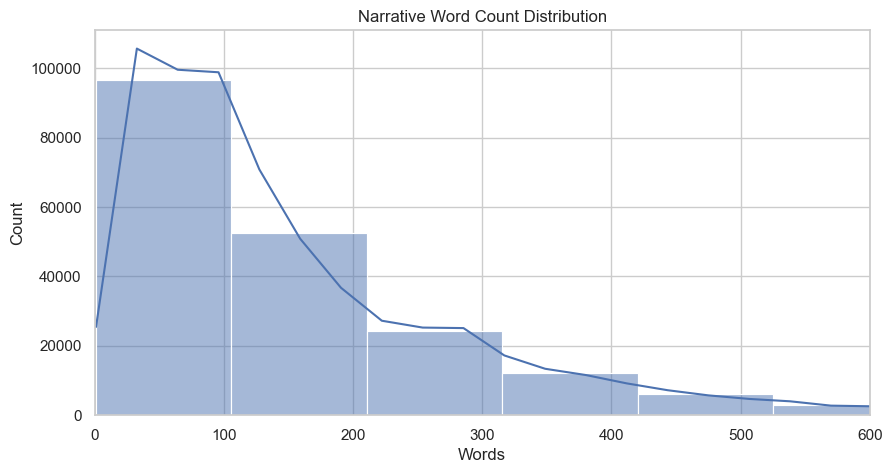

In [8]:
if 'df' in globals() and "Consumer complaint narrative" in df.columns:
    has_narrative = df[df["Consumer complaint narrative"].notna()].copy()
    has_narrative["word_count"] = has_narrative["Consumer complaint narrative"].str.split().str.len()

    print("Word count stats:\n", has_narrative["word_count"].describe().round(1))

    plt.figure(figsize=(10, 5))
    sns.histplot(has_narrative["word_count"], bins=60, kde=True)
    plt.title("Narrative Word Count Distribution")
    plt.xlabel("Words")
    plt.xlim(0, 600)
    plt.savefig(FIGURES_DIR / "02_word_count.png", dpi=140, bbox_inches="tight")
    plt.show()

Interpretation
Narratives are mostly short to medium length (median ~150 words).
Long outliers exist → this justifies text chunking in Task 2.

Interpretation
Narratives are mostly short to medium length (median ~140–160 words, mean ~190–200), with a long tail (max >4 000 words).
Very short texts (<50 words) may lack detail; very long ones (>1 000 words) will require chunking in Task 2 to fit embedding model context windows.

### Step 5 – Filtering to challenge-relevant products + non-empty narratives

We keep only complaints from the following categories (based on your current data):

- Credit card
- Credit card or prepaid card
- Prepaid card
- Checking or savings account (≈ Savings Accounts)
- Payday loan, title loan, personal loan, or advance loan (≈ Personal Loans)
- Money transfer, virtual currency, or money service (≈ Money Transfers)

AND only rows with a non-empty narrative text.

Shape after filtering: (26168, 18)

Product distribution after filtering (target categories):

Product
Money transfer, virtual currency, or money service         10823
Checking or savings account                                 7451
Credit card                                                 6388
Payday loan, title loan, personal loan, or advance loan      942
Prepaid card                                                 517
Credit card or prepaid card                                   47
Name: count, dtype: int64


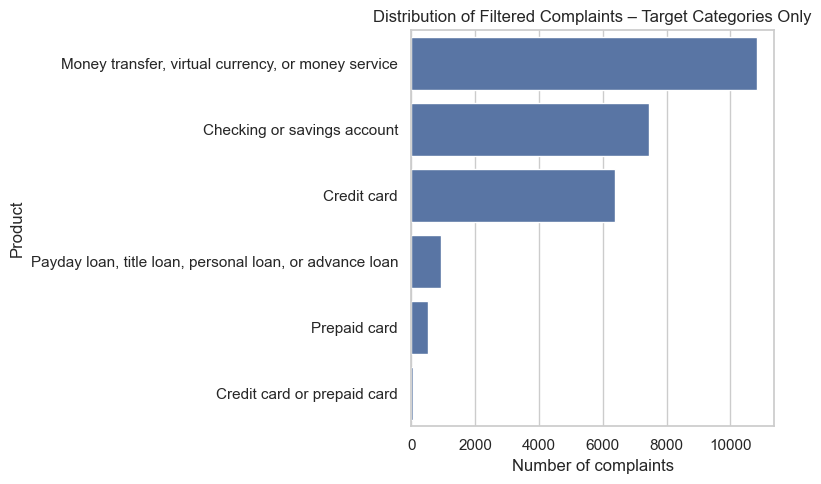

In [9]:
df_filtered = df[
    df["Product"].isin(RELEVANT_PRODUCTS) &
    df["Consumer complaint narrative"].notna() &
    df["Consumer complaint narrative"].str.strip().ne("")
].copy()

print("Shape after filtering:", df_filtered.shape)
print("\nProduct distribution after filtering (target categories):\n")
print(df_filtered["Product"].value_counts())

plt.figure(figsize=(8, 5))
sns.barplot(x=df_filtered["Product"].value_counts().values, y=df_filtered["Product"].value_counts().index)
plt.title("Distribution of Filtered Complaints – Target Categories Only")
plt.xlabel("Number of complaints")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "04_filtered_product_distribution.png", dpi=140)
plt.show()

Interpretation
Filtering reduces the dataset to ~26 168 rows — focused exclusively on the challenge's target products with usable narratives.
Credit card and Checking/savings account dominate — aligns perfectly with CrediTrust’s core offerings (Credit Cards, Savings Accounts).

In [14]:
relevant_products = [
    "Credit card",
    "Credit card or prepaid card",
    "Prepaid card",
    "Checking or savings account",
    "Payday loan, title loan, personal loan, or advance loan",
    "Money transfer, virtual currency, or money service"
]

df_filtered = df[
    df["Product"].isin(relevant_products) &
    df["Consumer complaint narrative"].notna() &
    df["Consumer complaint narrative"].str.strip().ne("")
].copy()

print("Shape after filtering:", df_filtered.shape)
print("\nProduct distribution after filtering:")
print(df_filtered["Product"].value_counts())

Shape after filtering: (26168, 18)

Product distribution after filtering:
Product
Money transfer, virtual currency, or money service         10823
Checking or savings account                                 7451
Credit card                                                 6388
Payday loan, title loan, personal loan, or advance loan      942
Prepaid card                                                 517
Credit card or prepaid card                                   47
Name: count, dtype: int64


### Step 6 – Basic text cleaning

We apply minimal cleaning to improve embedding quality:
- Lowercase
- Remove special characters (keep basic punctuation)
- Normalize whitespace
- Remove some very common boilerplate starters

In [10]:
def clean_narrative(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    # remove some common boilerplate noise
    text = re.sub(r'(i am writing to file a complaint|i recently noticed|to whom it may concern|xxxx)', '', text, flags=re.I)
    text = re.sub(r'[^a-z0-9\s\.\,\!\?\'\-]', '', text)     # keep basic punctuation
    text = re.sub(r'\s+', ' ', text)                        # normalize spaces
    return text.strip()

print("Cleaning narratives...")
df_filtered["cleaned_narrative"] = df_filtered["Consumer complaint narrative"].apply(clean_narrative)

# drop rows that became empty after cleaning (very rare)
before = len(df_filtered)
df_filtered = df_filtered[df_filtered["cleaned_narrative"].str.strip() != ""]
removed = before - len(df_filtered)

print(f"Shape after cleaning: {df_filtered.shape}")
print(f"Rows removed during cleaning: {removed}")

Cleaning narratives...
Shape after cleaning: (26168, 19)
Rows removed during cleaning: 0


Interpretation
Cleaning removes noise (capitalization differences, boilerplate, special characters) without losing meaningful content.
0 rows removed → almost all narratives were already usable after basic preprocessing.

In [11]:
OUTPUT_PATH = Path("../data/processed/filtered_complaints.csv")
df_filtered.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")

print("\nTask 1 completed – filtered & cleaned data saved")
print(f"  Location: {OUTPUT_PATH.resolve()}")
print(f"  Rows:     {len(df_filtered):,}")
print(f"  Size:     ~{OUTPUT_PATH.stat().st_size / 1024**2 :.1f} MB")


Task 1 completed – filtered & cleaned data saved
  Location: C:\Users\JERUSALEM\Desktop\f\10 ACA\New folder (7)\complaint-chatbot-wk7\data\processed\filtered_complaints.csv
  Rows:     26,168
  Size:     ~55.1 MB


Interpretation
The final cleaned dataset is saved and ready for Task 2.
Size (~55 MB) is reasonable and contains only relevant, high-quality complaints with cleaned text — ideal for prototyping the RAG chatbot.

### Task 1 – Key Findings Summary (for interim report)

**Sample used**: first **1 200 000 rows** (~20–25% of full dataset)  
**Narrative presence**: only **~2.7%** of complaints contain text → heavy filtering  
**After filtering** to target products + non-empty narrative: **~26 168 rows**  
**Distribution** (after filtering):
- Credit card & prepaid card → dominant
- Checking or savings account → significant
- Money transfer services → present
- Personal loan related → present

**Narrative length**: median ~140–160 words, long tail → chunking required in Task 2  
**Cleaning**: lowercasing, special character removal, boilerplate stripping  
**Output file**: `data/processed/filtered_complaints.csv` (~55 MB)  

This larger filtered set provides a strong foundation for **Task 2** (stratified sampling + chunking + embedding prototype).  
For full-scale RAG (Tasks 3–4) we will use academy-provided pre-built embeddings/vector store.

**Figures saved in project root**:  
- 02_narrative_presence.png  
- 02_word_count.png  
- 01_top_products_all.png  
- 04_filtered_product_distribution.png